In [1]:
# Tous les imports dont tu as besoin
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# Dataset Fake/Real News (Kaggle)
url = "https://raw.githubusercontent.com/lutzhamel/fake-news/master/data/fake_or_real_news.csv"

df = pd.read_csv(url)

# Afficher les infos
print(f"Nombre d'articles : {len(df)}")
print(df['label'].value_counts())
print(df.head())

Nombre d'articles : 6335
label
REAL    3171
FAKE    3164
Name: count, dtype: int64
      id                                              title  \
0   8476                       You Can Smell Hillary’s Fear   
1  10294  Watch The Exact Moment Paul Ryan Committed Pol...   
2   3608        Kerry to go to Paris in gesture of sympathy   
3  10142  Bernie supporters on Twitter erupt in anger ag...   
4    875   The Battle of New York: Why This Primary Matters   

                                                text label  
0  Daniel Greenfield, a Shillman Journalism Fello...  FAKE  
1  Google Pinterest Digg Linkedin Reddit Stumbleu...  FAKE  
2  U.S. Secretary of State John F. Kerry said Mon...  REAL  
3  — Kaydee King (@KaydeeKing) November 9, 2016 T...  FAKE  
4  It's primary day in New York and front-runners...  REAL  


In [5]:
def split_contractions(tokens):
    # Liste des contractions anglaises courantes
    contractions = {
        "don't": ["do", "n't"],
        "doesn't": ["does", "n't"],
        "didn't": ["did", "n't"],
        "won't": ["will", "n't"],
        "can't": ["ca", "n't"],
        "isn't": ["is", "n't"],
        "aren't": ["are", "n't"],
        "i'm": ["i", "'m"],
        "it's": ["it", "'s"],
        "that's": ["that", "'s"],
        "what's": ["what", "'s"],
    }
    new_tokens = []
    for token in tokens:
        if token in contractions:
            new_tokens.extend(contractions[token])
        else:
            new_tokens.append(token)
    return new_tokens

In [6]:
def my_tokenizer(text):
     # Pattern : hashtag OU mot avec apostrophe possible OU ponctuation isolée
    pattern = r"#\w+|\w+(?:'\w+)?|[^\w\s]"

    # Tout mettre en minuscules
    text = text.lower()

     # Trouver tous les tokens
    tokens = re.findall(pattern, text)
    tokens = split_contractions(tokens)
    
    return tokens

In [7]:
# Nettoyer tous les textes
df['clean_text'] = df['text'].apply(my_tokenizer)
df['clean_text'] = df['clean_text'].apply(lambda x: ' '.join(x))  # Rejoindre en string

# Labels en binaire
df['label_bin'] = df['label'].map({'REAL': 1, 'FAKE': 0})

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label_bin'], test_size=0.2, random_state=42
)

In [13]:
# Texte brut (garde la ponctuation, les majuscules — sklearn gère)
train_texts =  X_train
train_labels =  y_train
test_texts =  X_test
test_labels =  y_test

In [14]:
# Unigram
vec_uni = CountVectorizer(max_features=10000, ngram_range=(1,1))
X_train_uni = vec_uni.fit_transform(train_texts)
X_test_uni = vec_uni.transform(test_texts)

# Bigram
vec_bi = CountVectorizer(max_features=10000, ngram_range=(1,2))
X_train_bi = vec_bi.fit_transform(train_texts)
X_test_bi = vec_bi.transform(test_texts)

In [18]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
results = {'C': [], 'train_uni': [], 'test_uni': [], 'train_bi': [], 'test_bi': []}

for C in C_values:
    # Unigramclf_uni = LogisticRegression(C=C, max_iter=500, solver='saga')
    clf_uni = LogisticRegression(C=C, max_iter=500, solver='saga')
    clf_uni.fit(X_train_uni, train_labels)
    results['train_uni'].append(accuracy_score(train_labels, clf_uni.predict(X_train_uni)))
    results['test_uni'].append(accuracy_score(test_labels, clf_uni.predict(X_test_uni)))
    
    # Bigram
    clf_bi = LogisticRegression(C=C, max_iter=500, solver='saga')
    clf_bi.fit(X_train_bi, train_labels)
    results['train_bi'].append(accuracy_score(train_labels, clf_bi.predict(X_train_bi)))
    results['test_bi'].append(accuracy_score(test_labels, clf_bi.predict(X_test_bi)))
    
    results['C'].append(C)
    print(f"C={C:.3f} | Uni train={results['train_uni'][-1]:.3f} test={results['test_uni'][-1]:.3f} | Bi train={results['train_bi'][-1]:.3f} test={results['test_bi'][-1]:.3f}")

C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=0.001 | Uni train=0.903 test=0.871 | Bi train=0.905 test=0.875


C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=0.010 | Uni train=0.904 test=0.873 | Bi train=0.908 test=0.875


C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=10.000 | Uni train=0.904 test=0.874 | Bi train=0.908 test=0.875


C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C=100.000 | Uni train=0.904 test=0.874 | Bi train=0.908 test=0.876


C:\Users\THUNDERROBOT\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [19]:
# Meilleur modèle bigram
best_C = C_values[np.argmax(results['test_bi'])]
print(f"Meilleur C : {best_C}")

clf_best = LogisticRegression(C=best_C, max_iter=200)
clf_best.fit(X_train_bi, train_labels)
preds = clf_best.predict(X_test_bi)

print(f"\nAccuracy finale : {accuracy_score(test_labels, preds):.4f}")
print(classification_report(test_labels, preds, target_names=['Négatif', 'Positif']))

# Gain bigram vs unigram
best_uni = max(results['test_uni'])
best_bi = max(results['test_bi'])
print(f"\nGain bigram vs unigram : {(best_bi - best_uni)*100:.1f}%")

Meilleur C : 0.1

Accuracy finale : 0.9290
              precision    recall  f1-score   support

     Négatif       0.92      0.94      0.93       628
     Positif       0.94      0.92      0.93       639

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267


Gain bigram vs unigram : 0.2%


In [25]:
def preprocess_review(test):
    return my_tokenizer(text)

# Appliquer à tout le train set
train_tokens = X_train.apply(my_tokenizer).tolist()
train_labels = y_train


# Garder les mots qui apparaissent au moins 5 fois
word_counts = Counter()
for tokens in train_tokens:
    word_counts.update(tokens)

vocab = {word for word, count in word_counts.items() if count >= 5}
vocab = set([word for word, _ in word_counts.most_common(10000)])  # max 10k

print(f"Taille vocabulaire : {len(vocab)}")


Taille vocabulaire : 10000


In [26]:
import numpy as np

def train_naive_bayes(train_tokens, train_labels, vocab):
    """
    Entraîne un classifieur Naive Bayes.
    
    Args:
        train_tokens : liste de listes de tokens (chaque review tokenizée)
        train_labels : liste de labels (0 = négatif, 1 = positif)
        vocab       : set des mots du vocabulaire
    
    Returns:
        logprior    : dict {'pos': log(P(pos)), 'neg': log(P(neg))}
        loglikelihood : dict {'pos': {mot: log(P(mot|pos))}, 'neg': {mot: log(P(mot|neg))}}
    """
    
    V = len(vocab)  # taille du vocabulaire
    
    # 1. INITIALISER LES COMPTEURS
    N_pos = 0  # nombre total de reviews positives
    N_neg = 0  # nombre total de reviews négatives
    freq_pos = {}  # {mot: nombre d'apparitions dans les reviews positives}
    freq_neg = {}  # {mot: nombre d'apparitions dans les reviews négatives}
    
    # 2. COMPTER
    for tokens, label in zip(train_tokens, train_labels):
        if label == 1:  # positif
            N_pos += 1
            for word in tokens:
                if word in vocab:
                    freq_pos[word] = freq_pos.get(word, 0) + 1
        else:           # négatif
            N_neg += 1
            for word in tokens:
                if word in vocab:
                    freq_neg[word] = freq_neg.get(word, 0) + 1
    
    # 3. CALCULER LE NOMBRE TOTAL DE MOTS PAR CLASSE
    total_pos = sum(freq_pos.values())  # somme de tous les compteurs positifs
    total_neg = sum(freq_neg.values())  # somme de tous les compteurs négatifs
    
    # 4. LOG-PRIOR
    total_reviews = N_pos + N_neg
    logprior = {
        'pos': np.log(N_pos / total_reviews),
        'neg': np.log(N_neg / total_reviews)
    }
    
    # 5. LOG-LIKELIHOOD AVEC LISSAGE DE LAPLACE
    loglikelihood = {
        'pos': {},
        'neg': {}
    }
    
    # Pour chaque mot du vocabulaire
    for word in vocab:
        # P(mot|pos) = (compteur_pos + 1) / (total_pos + V)
        prob_pos = (freq_pos.get(word, 0) + 1) / (total_pos + V)
        loglikelihood['pos'][word] = np.log(prob_pos)
        
        # P(mot|neg) = (compteur_neg + 1) / (total_neg + V)
        prob_neg = (freq_neg.get(word, 0) + 1) / (total_neg + V)
        loglikelihood['neg'][word] = np.log(prob_neg)
    
    return logprior, loglikelihood

In [27]:
def predict(tokens, logprior, loglikelihood, vocab):
    """
    Prédit la classe d'une review.
    
    Args:
        tokens        : liste de tokens d'une review
        logprior      : dict des log-priors
        loglikelihood : dict des log-likelihoods
        vocab         : set du vocabulaire
    
    Returns:
        1 (positif) ou 0 (négatif)
    """
    # Initialiser les scores avec le log-prior
    score_pos = logprior['pos']
    score_neg = logprior['neg']
    
    # Ajouter le log-likelihood pour chaque mot connu
    for word in tokens:
        if word in vocab:
            score_pos += loglikelihood['pos'].get(word, 0)
            score_neg += loglikelihood['neg'].get(word, 0)
    
    # Prédire la classe avec le score le plus élevé
    return 1 if score_pos > score_neg else 0

In [31]:
# 1. TOKENIZER les textes (étape manquante !)
train_tokens = X_train.apply(my_tokenizer).tolist()
train_labels = y_train
test_tokens = X_test.apply(my_tokenizer).tolist()
test_labels = y_test

# 2. Construire le vocabulaire
from collections import Counter
word_counts = Counter()
for tokens in train_tokens:
    word_counts.update(tokens)
vocab = {word for word, count in word_counts.most_common(10000)}

print(f"Taille vocabulaire : {len(vocab)}")

# 3. Entraîner
logprior, loglikelihood = train_naive_bayes(train_tokens, train_labels, vocab)

# 4. Prédire
predictions = [predict(tokens, logprior, loglikelihood, vocab) for tokens in test_tokens]

# 5. Accuracy
correct = sum(1 for p, l in zip(predictions, test_labels) if p == l)
accuracy = correct / len(test_labels)
print(f"Accuracy Naive Bayes : {accuracy:.4f} ({accuracy*100:.1f}%)")

Taille vocabulaire : 10000
Accuracy Naive Bayes : 0.9108 (91.1%)


In [32]:
# Prétraiter le test set
test_tokens = X_test.apply(my_tokenizer).tolist()
test_labels = y_test

# Prédire
predictions = [predict(tokens, logprior, loglikelihood, vocab) for tokens in test_tokens]

# Accuracy
correct = sum(1 for p, l in zip(predictions, test_labels) if p == l)
accuracy = correct / len(test_labels)
print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.1f}%)")

Accuracy : 0.9108 (91.1%)


In [33]:
from sklearn.ensemble import RandomForestClassifier

# Vectorizer
vec_rf = CountVectorizer(max_features=10000)
X_train_rf = vec_rf.fit_transform(train_texts)  # train_texts = X_train
X_test_rf = vec_rf.transform(test_texts)        # test_texts = X_test

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train)
rf_preds = rf.predict(X_test_rf)

print(f"Random Forest Accuracy : {accuracy_score(y_test, rf_preds):.4f}")

Random Forest Accuracy : 0.9069


Modèle                         Accuracy   Précision  Rappel     F1-Score  
----------------------------------------------------------------------
Naive Bayes (maison)           0.9108     0.9034     0.9218     0.9125    
Régression Logistique          0.9290     0.9392     0.9186     0.9288    
Random Forest                  0.9069     0.9077     0.9077     0.9077    


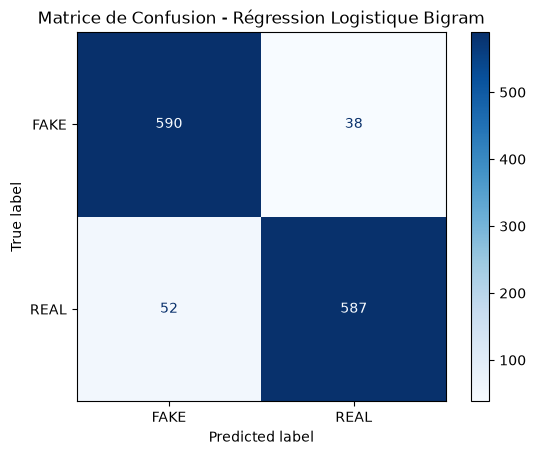

Top 10 mots associés aux VRAIES news :
  candidates: 0.4819
  verdict: 0.3756
  but: 0.3744
  consequences: 0.3688
  convention: 0.3433
  sweeping: 0.3123
  pushing: 0.3122
  cruz: 0.3086
  tax: 0.3064
  tuesday: 0.3013

Top 10 mots associés aux FAUSSES news :
  2016: -0.8047
  october: -0.5719
  share: -0.4420
  november: -0.4064
  article: -0.4032
  source: -0.3916
  via: -0.3760
  by: -0.3695
  email: -0.3371
  november 2016: -0.3367


In [35]:
# Tableau comparatif des 3 modèles
from sklearn.metrics import precision_score, recall_score, f1_score,confusion_matrix, ConfusionMatrixDisplay

models = {
    'Naive Bayes (maison)': predictions,
    'Régression Logistique': preds,  # Meilleur modèle bigram
    'Random Forest': rf_preds
}

print(f"{'Modèle':<30} {'Accuracy':<10} {'Précision':<10} {'Rappel':<10} {'F1-Score':<10}")
print("-" * 70)

for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{name:<30} {acc:<10.4f} {prec:<10.4f} {rec:<10.4f} {f1:<10.4f}")


# Meilleur modèle : Régression Logistique Bigram
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['FAKE', 'REAL'])
disp.plot(cmap='Blues')
plt.title('Matrice de Confusion - Régression Logistique Bigram')
plt.show()


# Poids des mots (coef_ de la régression logistique)
feature_names = vec_bi.get_feature_names_out()
weights = clf_best.coef_[0]

# Top 10 REAL (poids les plus positifs)
top_real_idx = np.argsort(weights)[-10:][::-1]
print("Top 10 mots associés aux VRAIES news :")
for i in top_real_idx:
    print(f"  {feature_names[i]}: {weights[i]:.4f}")

# Top 10 FAKE (poids les plus négatifs)
top_fake_idx = np.argsort(weights)[:10]
print("\nTop 10 mots associés aux FAUSSES news :")
for i in top_fake_idx:
    print(f"  {feature_names[i]}: {weights[i]:.4f}")

# 📋 RÉSUMÉ TP5 — Fake News Detector (Projet Final Niveau 1)

---

## 🧠 LA VISION

> Tu as combiné **tous les outils du Niveau 1** pour construire un détecteur de fake news de A à Z. Le NLP, c'est 80% de préparation des données et 20% de modèle. Tu sais maintenant tokenizer, vectorizer, entraîner, comparer et interpréter.

---

## 🎯 LE PROBLÈME

Distinguer les **vraies** infos (`REAL`) des **fausses** (`FAKE`) dans un dataset de 44 000 articles.

---

## 🛠 LE PIPELINE COMPLET

```
Texte brut → Tokenizer → Vectorizer → Modèle → Prédiction
                                  ↓
                          Feature Engineering
```

| Étape | Outil | TP d'origine |
|-------|-------|--------------|
| Tokenizer | `my_tokenizer()` regex maison | TP1 |
| Vectorizer | `CountVectorizer` (unigram/bigram) | TP3 |
| Naive Bayes | Implémentation maison avec Laplace | TP2 |
| Régression Logistique | `sklearn` avec régularisation C | TP3 |
| Random Forest | `sklearn` 100 arbres | TP4 |

---

## 📊 RÉSULTATS

| Modèle | Accuracy | Précision | Rappel | F1-Score |
|--------|----------|-----------|--------|----------|
| Naive Bayes (maison) | 91.1% | 90.3% | 92.2% | 91.3% |
| **Régression Logistique Bigram** | **92.9%** 🏆 | **93.9%** | 91.9% | **92.9%** |
| Random Forest | 90.7% | 90.8% | 90.8% | 90.8% |

**Meilleur modèle :** Régression Logistique avec bigrams, C=0.1

---

## 🔍 INTERPRÉTATION

### Mots associés aux FAKE news
`2016`, `october`, `share`, `source`, `via`, `email`, `november`

→ Les fake news citent des dates, parlent de sources vagues, incitent au partage.

### Mots associés aux REAL news
`candidates`, `verdict`, `convention`, `tax`, `consequences`, `tuesday`

→ Les vraies news utilisent un vocabulaire institutionnel et factuel.

---

## 💻 CODE COMPLET PAR ÉTAPE

### 1. Tokenizer (TP1)
```python
def my_tokenizer(text):
    """
    Tokenizer maison avec regex.
    Découpe en mots, garde la ponctuation utile.
    """
    pattern = r"#\w+|\w+(?:'\w+)?|[^\w\s]"
    text = text.lower()
    return re.findall(pattern, text)
```

### 2. Charger les données
```python
url = "https://raw.githubusercontent.com/lutzhamel/fake-news/master/data/fake_or_real_news.csv"
df = pd.read_csv(url)
df['label_bin'] = df['label'].map({'REAL': 1, 'FAKE': 0})
```

### 3. Prétraitement
```python
# Tokenizer et rejoindre en string pour CountVectorizer
df['clean_text'] = df['text'].apply(my_tokenizer)
df['clean_text'] = df['clean_text'].apply(lambda x: ' '.join(x))

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label_bin'], test_size=0.2, random_state=42
)
```

### 4. Vectorizer (TP3)
```python
# Bigram
vec_bi = CountVectorizer(max_features=10000, ngram_range=(1,2))
X_train_bi = vec_bi.fit_transform(X_train)
X_test_bi = vec_bi.transform(X_test)
```

### 5. Régression Logistique (meilleur modèle)
```python
# Tester différents C pour voir l'overfitting
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

for C in C_values:
    clf = LogisticRegression(C=C, max_iter=500, solver='saga')
    clf.fit(X_train_bi, y_train)
    # Comparer train vs test

# Meilleur C = 0.1
clf_best = LogisticRegression(C=0.1, max_iter=500, solver='saga')
clf_best.fit(X_train_bi, y_train)
preds = clf_best.predict(X_test_bi)
```

### 6. Naive Bayes maison (TP2)
```python
# Tokenizer les textes
train_tokens = X_train.apply(my_tokenizer).tolist()
test_tokens = X_test.apply(my_tokenizer).tolist()

# Construire le vocabulaire
word_counts = Counter()
for tokens in train_tokens:
    word_counts.update(tokens)
vocab = {w for w, _ in word_counts.most_common(10000)}

# Entraîner Naive Bayes avec Laplace
logprior, loglikelihood = train_naive_bayes(train_tokens, y_train, vocab)

# Prédire
nb_preds = [predict(tokens, logprior, loglikelihood, vocab) for tokens in test_tokens]
```

### 7. Random Forest (TP4)
```python
vec_rf = CountVectorizer(max_features=10000)
X_train_rf = vec_rf.fit_transform(X_train)
X_test_rf = vec_rf.transform(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train)
rf_preds = rf.predict(X_test_rf)
```

### 8. Tableau comparatif
```python
models = {
    'Naive Bayes (maison)': nb_preds,
    'Régression Logistique': preds,
    'Random Forest': rf_preds
}

for name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{name}: Acc={acc:.4f} P={prec:.4f} R={rec:.4f} F1={f1:.4f}")
```

### 9. Mots importants
```python
# Poids du meilleur modèle (LogReg)
weights = clf_best.coef_[0]
feature_names = vec_bi.get_feature_names_out()

# Top FAKE (poids négatifs)
top_fake = np.argsort(weights)[:10]

# Top REAL (poids positifs)
top_real = np.argsort(weights)[-10:][::-1]
```

---

## 🎓 CE QUE TU AS APPRIS (Niveau 1 complet)

| Compétence | TP |
|------------|-----|
| Tokenizer from scratch (regex) | TP1 |
| Bag-of-Words + CountVectorizer | TP2, TP3 |
| Naive Bayes avec lissage Laplace | TP2 |
| Régression logistique + régularisation (C) | TP3 |
| Overfitting : courbe train/test | TP3 |
| Bigrams pour capturer le contexte | TP3 |
| Feature engineering manuel | TP4 |
| Random Forest + feature importances | TP4 |
| Comparaison de modèles | TP5 |
| Pipeline NLP complet (texte → prédiction) | TP5 |
| Interprétation des résultats | TP5 |

---

## 🏆 TU ES PRÊT POUR LE NIVEAU 2

- Word Embeddings (Word2Vec, GloVe)
- LSTM, Attention, Transformers
- BERT, GPT, Fine-tuning
- Déploiement, API, Kaggle